# Synthetic run-to-failure data from the dotime SCM generator

Generates the **synthetic RUL training data** for the PFN: multivariate sensor
histories with piecewise-linear RUL labels, produced entirely from structural
causal models — no real data involved.

Two modules under `src/rulbench/synthetic/`:

- **`rul_mechanism.py`** — the degradation + failure + response-surface layer. Pure
  numpy/sklearn functions of a trajectory (no dotime import), unit-tested in `tests/`.
- **`rul_prior.py`** — `RULPrior`, an adapter over dotime's `CausalTimePrior`. It reuses
  the SCM sampler and observational rollout unchanged and applies the mechanism layer.

The generative story, per machine **family**:

1. **One SCM = one family.** Rollouts of that SCM are the *units* of the family.
2. A family-level **failure mechanism** fixes which channel drives wear (the *stressor*)
   and how the sensors respond to it.
3. **Pilot rollouts calibrate the family**: the failure-threshold scale, the stressor
   normalization, and the RUL cap. All three are fixed *before* any unit is drawn, so the
   failure model is genuinely first-passage — the threshold never depends on the
   trajectory it is applied to.
4. Each unit accumulates a monotone **health** index at its own random ageing rate. The
   **first crossing** of the unit's threshold is the failure time `T_fail`. A unit whose
   health never reaches the threshold within the horizon is emitted as a
   **right-censored suspension** (`censored=True`, RUL label unknown) — like the
   suspended units real fleets contain.
5. Responsive sensors get a **degradation signature**: a random smooth function of
   health, so different families show different failure signatures.
6. The label is **piecewise-linear capped RUL**: `RUL(t) = min(T_fail − 1 − t, cap)` with
   the cap **constant per family** (the C-MAPSS / Heimes 2008 convention — the plateau
   does not encode a unit's own total life).

Sections: **1** single-unit walkthrough · **2** censoring · **3** summary table ·
**4** long table · **5** PFN batch · **6** configuration · **7** fleet view ·
**8** save.

In [1]:
# --- make the CausalTimePrior submodule + the synthetic package importable ---
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    """Walk up until we find the repo (has third_party/ or pyproject.toml)."""
    for d in [start, *start.parents]:
        if (d / "third_party").is_dir() or (d / "pyproject.toml").is_file():
            return d
    return start

ROOT = _find_repo_root(Path.cwd())
CTP  = ROOT / "third_party" / "CausalTimePrior"          # git submodule
DOPFN = ROOT / "third_party" / "Do-PFN-prior"            # git submodule (dopfnprior)
SYN  = ROOT / "src" / "rulbench" / "synthetic"           # this package

# Dev fallback: local dotime checkout if submodules aren't initialised yet.
if not (CTP / "causal_time_prior").exists():
    _dev = Path.home() / "Desktop" / "dotime" / "CausalTimePrior"
    if _dev.exists():
        CTP, DOPFN = _dev, _dev / "Do-PFN-prior"

for p in [SYN.parent.parent, CTP, DOPFN, SYN]:   # src/ (for `rulbench...`), submodules, package dir
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import pandas as pd
pd.set_option("display.max_columns", 40, "display.width", 160)
try:
    print("CausalTimePrior:", CTP.relative_to(ROOT))
except ValueError:                                       # dev fallback outside the repo
    print("CausalTimePrior: local dev checkout")

CausalTimePrior: third_party/CausalTimePrior


## 1. How one unit is made

The pipeline from raw SCM output to one labelled unit has seven stages. Each is a small
pure function in `rul_mechanism.py`; this section runs them one at a time on a single
unit so you can watch the transformation, then plots it.

1. **Roll out the SCM** (`scm.sample_observational`) → a raw multivariate series of shape
   `(T, N)`. This is dotime's generator used unchanged — no notion of failure yet.
   Divergent draws (dotime returns zeros) are rejected by `valid_trajectory`.
2. **Draw the failure mechanism** (`sample_mechanism`) → picks the *stressor* channel
   whose severity drives wear, chooses which channels will carry a degradation signature,
   and draws the random response-surface coefficients. Fixed once per family.
3. **Calibrate the family** (`calibrate_family`) → from a few *pilot* rollouts that never
   become units: `health_ref` (typical wear at the reference age `threshold_ref_time`),
   the stressor normalization, and the family RUL cap. Because these are estimated from
   pilots, a unit's threshold is independent of its own trajectory.
4. **Accumulate health** (`degradation_state`) → a monotone degradation index `d(t)` with
   a per-unit random ageing rate. Because the threshold is calibrated, a fast-ageing unit
   genuinely fails earlier and a slow one later (or not at all). Monotone ⇒ failure is
   *absorbing*.
5. **Find the failure time** (`failure_time`) → the unit's threshold is
   `θ = frac × health_ref`; `T_fail` is the first cycle with `d(t) ≥ θ`. No crossing
   within the horizon ⇒ the unit is a right-censored suspension (kept, see section 2).
6. **Stamp the degradation signature** (`apply_response_surface`) → push health through
   the family's random smooth response and add it to the responsive channels. All
   normalization constants (health scale, surface scale, channel scale) come from the
   family calibration or a fixed reference grid — never from the unit itself — so the
   sensor value at time `t` depends only on the wear reached at `t`, and a censored unit
   shows only the part of the signature its wear actually covered.
7. **Label** (`rul_label`) → `RUL(t) = min(T_fail − 1 − t, cap)` with the family cap.

In [2]:
# Run the seven stages on ONE unit, printing the salient value at each.
import io, contextlib
try:
    from rulbench.synthetic.rul_mechanism import (
        RulConfig, sample_mechanism, calibrate_family, degradation_state,
        failure_time, apply_response_surface, rul_label, valid_trajectory)
except ImportError:  # dev / flat layout
    from rul_mechanism import (
        RulConfig, sample_mechanism, calibrate_family, degradation_state,
        failure_time, apply_response_surface, rul_label, valid_trajectory)
from causal_time_prior.prior import CausalTimePrior

import torch
torch.manual_seed(0)          # seed the GLOBAL torch RNG too: dotime's SCM rollout
                              # leaks per-step noise draws to it (see rul_prior._scoped_rng),
                              # so this makes the walkthrough reproducible on re-run
cfg = RulConfig()
rng = np.random.default_rng(0)
ctp = CausalTimePrior(seed=0)
T_MAX = 200

def rollout(scm):
    """One observational rollout, or None if the SCM draw diverged."""
    with contextlib.redirect_stdout(io.StringIO()):        # silence dotime divergence notes
        raw = scm.sample_observational(T=T_MAX, burn_in=ctp.config["burn_in"],
                                       generator=ctp.generator)
    return valid_trajectory(raw, cfg)

# STEP 1 — pick one SCM family that produces stable rollouts
scm = next(s for s in (ctp.sample_scm() for _ in range(50)) if rollout(s) is not None)
N = len(scm._topo)
print(f"1. SCM family              : {N} channels")

# STEP 2 — family failure mechanism
mech = sample_mechanism(N, rng, cfg)
print(f"2. mechanism               : stressor=ch{mech.stressor}, "
      f"responsive channels={mech.responsive}, basis={type(mech.basis).__name__}")

# STEP 3 — calibrate the family on pilot rollouts (pilots are never units)
pilots = []
while len(pilots) < 3:
    X_p = rollout(scm)
    if X_p is not None:
        pilots.append(X_p)
calib = calibrate_family(pilots, mech, rng, cfg)
print(f"3. calibration (3 pilots)  : health_ref={calib.health_ref:.3f} "
      f"(wear at age {cfg.threshold_ref_time}), family RUL cap={calib.rul_cap}")

# STEPS 4+5 — accumulate health, find the first threshold crossing.
# Draws can come out censored (no crossing) or too short (< min_life); for the
# walkthrough we want one FAILED unit, so we resample until we get one.
for _ in range(100):
    X = rollout(scm)
    if X is None:
        continue
    health = degradation_state(X, mech, rng, cfg, calib.stressor_mu, calib.stressor_sd)
    T_fail, theta = failure_time(health, rng, cfg, calib)
    if T_fail is None:
        print("   (drew a censored unit — resampling; kept in real datasets, see §2)")
        continue
    if T_fail >= cfg.min_life:
        break
else:
    raise RuntimeError("no failed unit in 100 draws — check the config")
print(f"4. health d(t)             : monotone={bool(np.all(np.diff(health) >= 0))}, "
      f"d[0]={health[0]:.3f} -> d[-1]={health[-1]:.3f}")
print(f"5. failure                 : threshold theta={theta:.3f} "
      f"(= frac x health_ref, NOT a function of this unit) -> T_fail={T_fail} cycles")

# STEP 6 — degradation signature on responsive sensors (family-scaled)
sensors = apply_response_surface(X[:T_fail].copy(), health[:T_fail], mech, cfg, calib)
changed = [j for j in range(N) if np.abs(sensors[:, j] - X[:T_fail, j]).sum() > 1e-9]
print(f"6. response surface        : signature added to channels {changed}")

# STEP 7 — piecewise-linear capped RUL label (family cap)
rul = rul_label(T_fail, calib.rul_cap)
print(f"7. RUL label               : cap C={calib.rul_cap} (family constant), "
      f"RUL[0]={rul[0]:.0f} (plateau) ... RUL[-1]={rul[-1]:.0f} (failure)")

1. SCM family              : 10 channels
2. mechanism               : stressor=ch8, responsive channels=[0, 2, 3, 6, 8], basis=SplineTransformer


3. calibration (3 pilots)  : health_ref=2.256 (wear at age 100), family RUL cap=40
4. health d(t)             : monotone=True, d[0]=0.021 -> d[-1]=2.817
5. failure                 : threshold theta=1.344 (= frac x health_ref, NOT a function of this unit) -> T_fail=101 cycles
6. response surface        : signature added to channels [0, 2, 3, 6, 8]
7. RUL label               : cap C=40 (family constant), RUL[0]=40 (plateau) ... RUL[-1]=0 (failure)


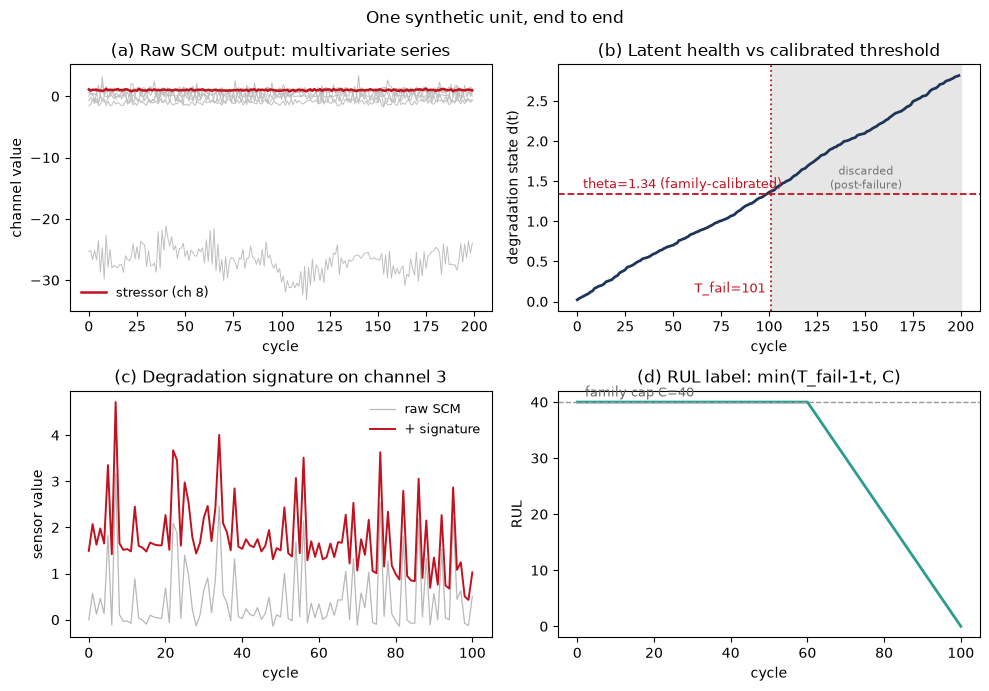

In [3]:
# Trace the same unit through the pipeline: raw -> health/threshold -> signature -> RUL.
import matplotlib.pyplot as plt

# most-changed responsive channel, for the signature panel
jsig = int(np.argmax([np.abs(sensors[:, j] - X[:T_fail, j]).sum() for j in range(N)]))
FOCAL, ALARM, HEALTH, RULC = "#c1121f", "#c1121f", "#1d3557", "#2a9d8f"
t_full, t_cut = np.arange(X.shape[0]), np.arange(T_fail)

fig, ax = plt.subplots(2, 2, figsize=(10, 7))

# (a) raw SCM output, stressor highlighted
for j in range(N):
    if j != mech.stressor:
        ax[0, 0].plot(t_full, X[:, j], color="0.75", lw=0.7)
ax[0, 0].plot(t_full, X[:, mech.stressor], color=FOCAL, lw=1.8,
              label=f"stressor (ch {mech.stressor})")
ax[0, 0].set(title="(a) Raw SCM output: multivariate series", xlabel="cycle",
             ylabel="channel value")
ax[0, 0].legend(frameon=False, fontsize=9)

# (b) health accumulates to the family-calibrated threshold -> T_fail
ax[0, 1].axvspan(T_fail, X.shape[0], color="0.90")
ax[0, 1].plot(t_full, health, color=HEALTH, lw=2)
ax[0, 1].axhline(theta, ls="--", color=ALARM, lw=1.3)
ax[0, 1].axvline(T_fail, ls=":", color=ALARM, lw=1.3)
ax[0, 1].annotate(f"theta={theta:.2f} (family-calibrated)", (3, theta), xytext=(0, 4),
                  textcoords="offset points", color=ALARM, fontsize=9)
ax[0, 1].annotate(f"T_fail={T_fail}", (T_fail, health.max() * 0.04), xytext=(-4, 0),
                  textcoords="offset points", ha="right", color=ALARM, fontsize=9)
ax[0, 1].text(T_fail + (X.shape[0] - T_fail) / 2, health.max() * 0.5,
              "discarded\n(post-failure)", ha="center", fontsize=8, color="0.45")
ax[0, 1].set(title="(b) Latent health vs calibrated threshold", xlabel="cycle",
             ylabel="degradation state d(t)")

# (c) one responsive channel: raw vs with degradation signature
ax[1, 0].plot(t_cut, X[:T_fail, jsig], color="0.72", lw=0.9, label="raw SCM")
ax[1, 0].plot(t_cut, sensors[:, jsig], color=FOCAL, lw=1.4, label="+ signature")
ax[1, 0].set(title=f"(c) Degradation signature on channel {jsig}", xlabel="cycle",
             ylabel="sensor value")
ax[1, 0].legend(frameon=False, fontsize=9)

# (d) the label: piecewise-linear RUL, plateau at the family cap
ax[1, 1].plot(t_cut, rul, color=RULC, lw=2)
ax[1, 1].axhline(calib.rul_cap, ls="--", color="0.6", lw=1)
ax[1, 1].annotate(f"family cap C={calib.rul_cap}", (2, calib.rul_cap), xytext=(0, 4),
                  textcoords="offset points", fontsize=9, color="0.4")
ax[1, 1].set(title="(d) RUL label: min(T_fail-1-t, C)", xlabel="cycle", ylabel="RUL")

fig.suptitle("One synthetic unit, end to end", fontsize=12)
fig.tight_layout()
plt.show()

### Which channels carry the signature?

Panel (c) above showed just one channel. Here are **all `N` channels of the same unit** —
so you can see that only some of them react to wear:

- **Which** channels are responsive is **random** (`rng.choice`).
- **How many** is `max(1, round(responsive_frac * N))`. With the default
  `responsive_frac=0.5` and `N=10` that is always **5**; for a family with `N=3` it is 2.
  To force a single responsive channel, lower `responsive_frac` (e.g. `0.1`). In **fleet**
  mode `N` itself varies across families (`sample_scm` draws `N ∈ [3, N_max]`), so the
  count varies *because `N` does*.
- The **stressor** channel may or may not be one of the responsive ones (drawn
  independently).
- Non-responsive channels stay **pure SCM noise** — no end-of-life trend — mimicking
  sensors that don't see the failure. Among responsive channels the trend direction is
  per-channel random (some rise, some fall, some are non-monotone), because each gets its
  own random response surface.

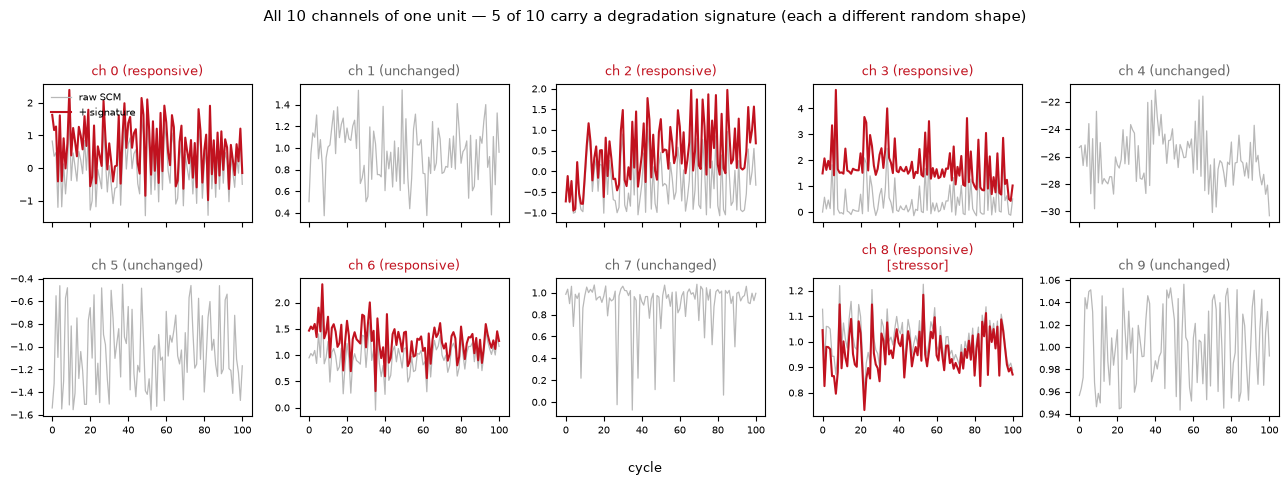

In [4]:
# All N channels of the walkthrough unit: responsive (red) vs untouched (grey).
ncols = min(N, 5); nrows = int(np.ceil(N / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(2.6 * ncols, 2.4 * nrows), sharex=True)
t = np.arange(T_fail)
for j, ax in enumerate(np.atleast_1d(axes).ravel()):
    if j >= N:
        ax.axis("off"); continue
    responsive = j in mech.responsive
    ax.plot(t, X[:T_fail, j], color="0.72", lw=0.9, label="raw SCM")
    if responsive:
        ax.plot(t, sensors[:, j], color="#c1121f", lw=1.5, label="+ signature")
    title = f"ch {j} " + ("(responsive)" if responsive else "(unchanged)")
    if j == mech.stressor:
        title += "\n[stressor]"
    ax.set_title(title, fontsize=9, color=("#c1121f" if responsive else "0.4"))
    ax.tick_params(labelsize=7)
    if j == 0:
        ax.legend(frameon=False, fontsize=7, loc="upper left")
fig.suptitle(f"All {N} channels of one unit — {len(mech.responsive)} of {N} carry a "
             f"degradation signature (each a different random shape)", fontsize=11)
fig.supxlabel("cycle", fontsize=9)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 2. Censoring: units that don't fail are data too

Because each unit ages at its own random rate against a **fixed** family threshold, some
units never reach it within the horizon. Those are **right-censored suspensions**: we
know the unit survived to the end of its record, but not when it would have failed.

Real fleets are full of these (a machine still running at data-collection time), and the
real benchmarks flag them (`datasets.py` has a per-unit `censored` flag) — so the prior
emits them too, in fleet mode:

- `censored=True`, `T_fail=None`, sensors observed over the **full horizon**;
- the RUL label is **all-NaN** — the true RUL is unknown, only bounded below;
- a family always contains at least **two failed units** (an in-context RUL task needs
  labeled examples); censored units appear alongside as they naturally occur.
- Raising `T_max` lowers the censoring rate without changing the failure times — with a
  first-passage model, a longer observation window just means fewer unresolved units.

In `trajectory` mode censored draws are resampled instead: a standalone unit without a
label is useless outside a fleet context.

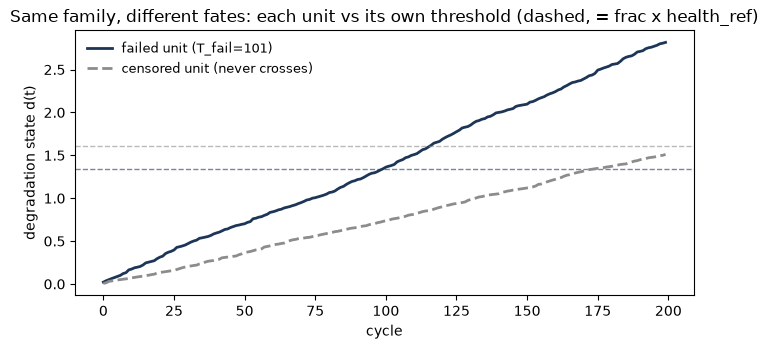

In [5]:
# Draw more units of the SAME family until one censors, then compare it to the
# failed walkthrough unit. Same mechanism, same calibration -- different ageing luck.
cens_health = None
for _ in range(300):
    X_c = rollout(scm)
    if X_c is None:
        continue
    h_c = degradation_state(X_c, mech, rng, cfg, calib.stressor_mu, calib.stressor_sd)
    tf_c, th_c = failure_time(h_c, rng, cfg, calib)
    if tf_c is None:
        cens_health = h_c
        break

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(np.arange(len(health)), health, color="#1d3557", lw=2,
        label=f"failed unit (T_fail={T_fail})")
ax.axhline(theta, ls="--", color="#1d3557", lw=1, alpha=0.6)
if cens_health is not None:
    ax.plot(np.arange(len(cens_health)), cens_health, color="0.55", lw=2, ls="--",
            label="censored unit (never crosses)")
    ax.axhline(th_c, ls="--", color="0.55", lw=1, alpha=0.6)
else:
    print("no censored draw in 300 tries for this family (low censor rate) — rerun or "
          "raise base_rate spread")
ax.set(title="Same family, different fates: each unit vs its own threshold "
             "(dashed, = frac x health_ref)",
       xlabel="cycle", ylabel="degradation state d(t)")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

## 3. One-call API → tables

`generate_rul_dataset(n, cfg, seed, task_mode)` returns `(long_df, summary_df, rows, prior)`.
In **fleet** mode (recommended), `n` is the number of *machine families*; each family is a
distinct SCM calibrated on its own pilots and rolled out into several units that share a
failure mechanism. Note the `censored` column and the per-family constant `rul_cap`.

In [6]:
try:
    from rulbench.synthetic import generate_rul_dataset, RulConfig
except ImportError:  # dev / flat layout
    from rul_prior import generate_rul_dataset
    from rul_mechanism import RulConfig

long_df, summary_df, rows, prior = generate_rul_dataset(
    n=5,                 # 5 machine families
    seed=3,
    T_max=160,           # rollout horizon; longer horizon = fewer censored units
    task_mode="fleet",   # "fleet" | "trajectory"
    cfg=RulConfig(),     # defaults: cumulative-stress degradation, spline response surface
)

n_cens = int(summary_df.censored.sum())
print(f"{summary_df.family_id.nunique()} families, {len(summary_df)} units "
      f"({n_cens} censored), {len(long_df):,} cycle-rows")
summary_df

5 families, 23 units (6 censored), 2,125 cycle-rows


,family_id,unit_id,n_sensors,censored,T_end,T_fail,rul_cap,threshold,n_responsive
0,0,0,6,True,160,NaN,39,1.8866,3
1,0,1,6,False,77,77.0,39,1.1153,3
2,0,2,6,False,66,66.0,39,2.1677,3
3,0,3,6,True,160,NaN,39,1.7904,3
4,1,0,8,False,40,40.0,38,2.2617,4
5,1,1,8,False,32,32.0,38,1.2172,4
6,1,2,8,False,82,82.0,38,1.2611,4
7,1,3,8,False,137,137.0,38,1.4449,4
8,2,0,5,True,160,NaN,39,1.3834,2
9,2,1,5,False,78,78.0,39,1.7003,2


## 4. The long table — sensors + health + RUL per cycle

The training-data view: each row is one cycle of one unit. `sensor_00..` are the (padded)
SCM channels carrying the degradation signature, `health` is the latent degradation
state, `RUL` is the capped piecewise-linear target — **NaN for censored units** (no label
exists there).

In [7]:
long_df.head(12)

,family_id,unit_id,cycle,censored,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,health,RUL
0,0,0,0,True,0.190778,0.363450,0.779351,-0.112975,-0.809301,-0.723700,NaN,NaN,NaN,0.010660,NaN
1,0,0,1,True,0.158348,-0.000875,-0.229824,0.240917,-0.781312,-0.275280,NaN,NaN,NaN,0.020769,NaN
2,0,0,2,True,0.313685,-0.076948,0.232395,-0.194677,-0.658425,-0.134867,NaN,NaN,NaN,0.028460,NaN
3,0,0,3,True,0.253363,-0.339031,-0.452170,-0.045877,-0.528324,-0.348972,NaN,NaN,NaN,0.033591,NaN
4,0,0,4,True,0.396718,-0.163264,0.253412,-0.049795,-0.013051,0.084489,NaN,NaN,NaN,0.043974,NaN
5,0,0,5,True,0.453773,-0.212313,-0.512403,0.096317,-0.533177,0.243932,NaN,NaN,NaN,0.049201,NaN
6,0,0,6,True,0.484848,0.130119,0.739518,0.101269,-0.495681,-0.151501,NaN,NaN,NaN,0.053689,NaN
7,0,0,7,True,0.517771,-0.475265,-1.075851,0.145340,-0.329054,-0.065018,NaN,NaN,NaN,0.057854,NaN
8,0,0,8,True,0.345544,-0.644809,-0.339126,0.036517,-0.593112,-0.292353,NaN,NaN,NaN,0.064261,NaN
9,0,0,9,True,0.154538,-0.413928,-0.356822,-0.148913,-0.631158,-0.201960,NaN,NaN,NaN,0.071417,NaN


In [8]:
# one failed unit, start to failure
f0, u0 = summary_df[~summary_df.censored].iloc[0][["family_id", "unit_id"]]
u = long_df[(long_df.family_id == f0) & (long_df.unit_id == u0)]
u[["cycle", "sensor_00", "sensor_01", "health", "RUL"]].iloc[::20]

,cycle,sensor_00,sensor_01,health,RUL
160,0,0.647729,-0.167897,0.012586,39.0
180,20,0.452819,-0.387687,0.282096,39.0
200,40,0.263077,0.098795,0.583608,36.0
220,60,0.286434,-0.192129,0.900433,16.0


## 5. Model-ready batch (for the PFN trainer)

`prior.generate_batch(rows)` returns padded arrays. Semantics of the masks:

- `step_mask` — True at observed cycles (False = padding);
- `variable_mask` — True at real channels (families have different `N`);
- `RUL` — NaN wherever **no label exists**: at pad positions *and* at all cycles of
  censored units;
- `label_mask` — `step_mask & ~isnan(RUL)`: True exactly where a loss term is valid.
  **Use this one in the trainer.**
- `censored` (B,) and `T_fail` (B, `-1` for censored units) carry the per-unit metadata.

Run the trainer with `target_key='RUL'`.

In [9]:
batch = prior.generate_batch(rows)
for k, v in batch.items():
    print(f"{k:14s} {getattr(v, 'shape', v)}")
print("\ncensored units in batch:", int(batch["censored"].sum()),
      "| labeled cycles:", int(batch["label_mask"].sum()),
      "of", int(batch["step_mask"].sum()), "observed")

sensors        (23, 160, 9)
RUL            (23, 160)
step_mask      (23, 160)
variable_mask  (23, 9)
label_mask     (23, 160)
censored       (23,)
T_fail         (23,)
target_key     RUL

censored units in batch: 6 | labeled cycles: 1165 of 2125 observed


## 6. Configuration switches

Structural choices:

- **`task_mode`** — `"fleet"` (cross-unit-within-family, matches deployment) vs
  `"trajectory"` (one SCM per unit, always failed).
- **`degradation_law`** — `"cumulative_stress"` (default) vs `"gamma"` / `"linear"`.
- **`surface_family`** — `"spline"` / `"nystroem"` (caussim-style random response
  surface) vs `"linear"` / `"none"` (ablation).

Lifetime knobs (all of them genuinely shape the data):

- **`threshold_ref_time`** (100) — reference age anchoring the family threshold scale. A
  median-rate unit fails around `frac × threshold_ref_time` cycles.
- **`threshold_frac_range`** (0.4, 0.9) — per-unit threshold draw, as a fraction of the
  family's calibrated wear scale.
- **`base_rate_log10_range`** — per-unit ageing-speed spread. Wider ⇒ more lifetime
  diversity within a family *and* a higher censoring rate (slow units stop crossing).
- **`T_max`** (rollout horizon, a `RULPrior` argument) — only trades censored for failed
  units; it does not stretch lifetimes.
- **`rul_cap_frac`** (0.6) — family cap = `round(frac × median pilot life)`.

These interact: if you widen one, sanity-check the resulting `summary_df` (lifetime
spread, censoring rate, `min_life` rejections) before generating at scale.

In [10]:
# example: gamma degradation + Nystroem surface, trajectory mode (all units failed)
cfg2 = RulConfig(degradation_law="gamma", surface_family="nystroem")
long2, summary2, rows2, prior2 = generate_rul_dataset(
    n=6, cfg=cfg2, seed=1, task_mode="trajectory")
summary2

,family_id,unit_id,n_sensors,censored,T_end,T_fail,rul_cap,threshold,n_responsive
0,0,0,6,False,24,24,38,1.3662,3
1,1,0,9,False,89,89,43,1.3347,4
2,2,0,4,False,88,88,39,1.4657,2
3,3,0,3,False,26,26,42,0.7299,2
4,4,0,5,False,183,183,44,1.8025,2
5,5,0,3,False,59,59,42,2.1070,2


## 7. Quick look at a synthetic fleet

Sensors, latent degradation, and the induced RUL label for the units of one family.
Censored units are drawn dashed grey: their health stays below the threshold band, and
they have no RUL curve — that is the point.

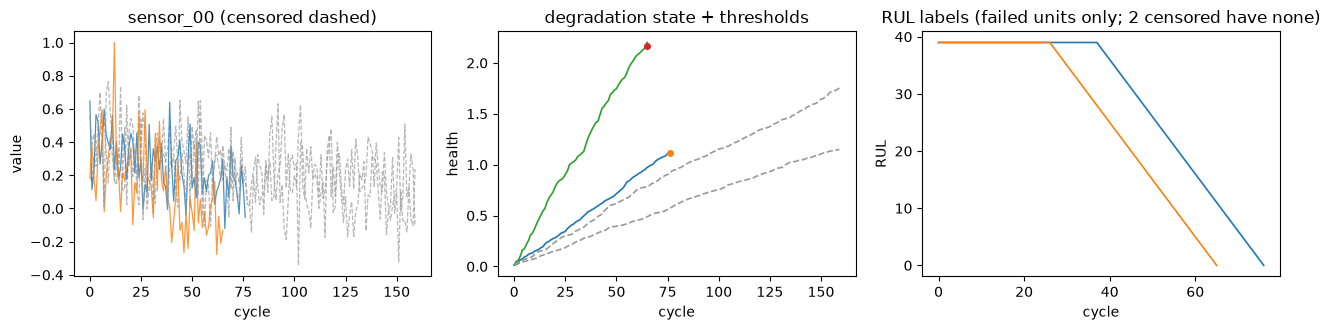

In [11]:
fam = [(u, s) for (f, u, s) in rows if f == 0]
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
for u, s in fam:
    if s.censored:
        ax[0].plot(s.sensors[:, 0], lw=0.9, alpha=0.7, color="0.6", ls="--")
        ax[1].plot(s.health, lw=1.2, color="0.6", ls="--")
    else:
        ax[0].plot(s.sensors[:, 0], lw=0.9, alpha=0.8)
        ax[1].plot(s.health, lw=1.2)
        ax[1].plot(s.T_fail - 1, s.threshold, "o", ms=4)
        ax[2].plot(s.rul, lw=1.2)
n_c = sum(s.censored for _, s in fam)
ax[0].set(title="sensor_00 (censored dashed)", xlabel="cycle", ylabel="value")
ax[1].set(title="degradation state + thresholds", xlabel="cycle", ylabel="health")
ax[2].set(title=f"RUL labels (failed units only; {n_c} censored have none)",
          xlabel="cycle", ylabel="RUL")
fig.tight_layout()
plt.show()

## 8. Save a dataset

The long table is a plain DataFrame — persist it however you like.

In [12]:
long_df.to_parquet("synthetic_rul_fleet.parquet", index=False)
print("wrote synthetic_rul_fleet.parquet:", long_df.shape)

wrote synthetic_rul_fleet.parquet: (2125, 15)
